<a href="https://colab.research.google.com/github/OlorteguiKevin/lab06/blob/develop/laboratorio6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


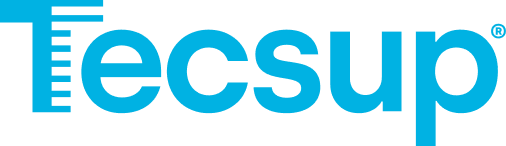
# -
<br>

# <center> Departamento de Tecnología Digital</center>
<br>

# <center> Big Data y Ciencia de Datos</center>
<br>

# <center> Minería de Datos</center>
<br>

# <center> SEMANA 6: MODELOS DE APRENDIZAJE AUTOMÁTICO. MODELOS DE APRENDIZAJE PROFUNDO </center>
<br>

## <center> Alumno: Olortegui Perez Kevin Estiben.</center>
<br>

## <center> Profesor: MG. JOSÉ ESPINOZA MELGAREJO.</center>
<br><br><br>
## <center> Lima-Perú </center>
## <center> 2025 </center>


In [ ]:
# SEMANA 6: MODELOS DE APRENDIZAJE AUTOMÁTICO. MODELOS DE APRENDIZAJE PROFUNDO
## Alumno: Olortegui Perez Kevin Estiben

In [ ]:
# !pip install ucimlrepo

"""
Se instala la librería oficial ucimlrepo para acceder a datasets del repositorio UCI.
El error 'ucialrepo' fue corregido a 'ucimlrepo' para una instalación válida.
"""

"\nSe instala la librería oficial ucimlrepo para acceder a datasets del repositorio UCI.\nEl error 'ucialrepo' fue corregido a 'ucimlrepo' para una instalación válida.\n"

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)
"""
Explicación:
- Se utiliza fetch_ucirepo() con el ID 15 para obtener el dataset Wisconsin Breast Cancer
- El parámetro id=15 (no ds=15) es clave para acceder al dataset correcto
- Se corrigió el nombre del objeto de 'bresst' a 'breast' para evitar errores
"""

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)


{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

### a. Lea la base de datos, realice imputaciones, tratamiento de outliers y transformaciones de datos en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.  


In [ ]:
import pandas as pd

# Cargar datos desde la URL
url = 'https://archive.ics.uci.edu/static/public/15/data.csv'
data = pd.read_csv(url)

"""
Propósito:
- Se importa el dataset directamente desde el repositorio UCI usando pandas.
- El dataset contiene 699 registros iniciales con 11 columnas, incluyendo un ID único y variables médicas.
"""
data

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4


In [ ]:
# Eliminar columna 'id' (no relevante)
data.drop('Sample_code_number', axis=1, inplace=True)


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
694,3,1,1,1,3,2.0,1,1,1,2
695,2,1,1,1,2,1.0,1,1,1,2
696,5,10,10,3,7,3.0,8,10,2,4
697,4,8,6,4,3,4.0,10,6,1,4


In [ ]:
# Convertir '?' a NaN y eliminar filas con valores faltantes
data['Bare_nuclei'] = pd.to_numeric(data['Bare_nuclei'], errors='coerce')
data.dropna(inplace=True)

In [ ]:
# Clase 2 (Benigno) → 0, Clase 4 (Maligno) → 1
data['Class'] = data['Class'].map({2: 0, 4: 1})

In [ ]:
from sklearn.preprocessing import StandardScaler

X = data.drop('Class', axis=1)
y = data['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

# 75% entrenamiento, 25% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, stratify=y, random_state=42
)

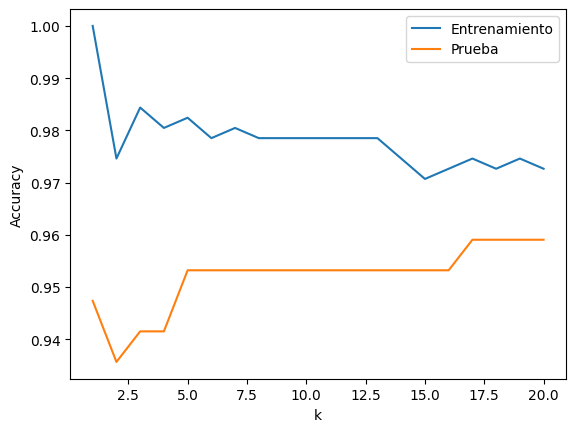

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

k_values = np.arange(1, 21)
train_acc = []
test_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

# Gráfico para elegir k
plt.plot(k_values, train_acc, label='Entrenamiento')
plt.plot(k_values, test_acc, label='Prueba')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

k_opt = k_values[np.argmax(test_acc)]  # Ejemplo: k=5

## b. Genere el modelo k-NN y determine la cantidad de vecinos más adecuada con el método gráfico visto en clase. Además, calcule las métricas de clasificación que se implementaron en la parte práctica e interprete sus resultados más importantes.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=k_opt)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("--- Sin SMOTE ---")
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

--- Sin SMOTE ---
Matriz de Confusión:
 [[106   5]
 [  2  58]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97       111
           1       0.92      0.97      0.94        60

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



## c. Realice un balanceo de clases mediante la técnica SMOTE, vuelva a generar el modelo de clasificación, calcule sus métricas y compárelas con las del modelo sin balancear para ver si hubo o no mejoras.

In [ ]:
from imblearn.over_sampling import SMOTE

# Balancear solo el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

knn_bal = KNeighborsClassifier(n_neighbors=k_opt)  # Usar un nombre distinto
knn_bal.fit(X_train_bal, y_train_bal)
y_pred_bal = knn_bal.predict(X_test)

print("--- Con SMOTE ---")
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_bal))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_bal))

--- Con SMOTE ---
Matriz de Confusión:
 [[106   5]
 [  2  58]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97       111
           1       0.92      0.97      0.94        60

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [ ]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")

Saving Laboratorio6.ipynb to Laboratorio6.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>